In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget

In [2]:
data_ref = pd.read_csv('Averaged_01_ref.txt', sep='\t', header=None, skiprows=0,
                       skipinitialspace=True, index_col=False, decimal=",", names=["time_ps", "signal"])

data_glass = pd.read_csv('Averaged_02_BS-12_glass.txt', sep='\t', header=None, skiprows=0,
                       skipinitialspace=True, index_col=False, decimal=",", names=["time_ps", "signal"])

data_plastic = pd.read_csv('Averaged_03_plastic.txt', sep='\t', header=None, skiprows=0,
                       skipinitialspace=True, index_col=False, decimal=",", names=["time_ps", "signal"])

data_linbo3 = pd.read_csv('Averaged_04_NbLiO3.txt', sep='\t', header=None, skiprows=0,
                       skipinitialspace=True, index_col=False, decimal=",", names=["time_ps", "signal"])

time_ps = data_ref["time_ps"].to_numpy()
signal_ref = data_ref["signal"].to_numpy()
signal_glass = data_glass["signal"].to_numpy()
signal_plastic = data_plastic["signal"].to_numpy()
signal_linbo3 = data_linbo3["signal"].to_numpy()

### Raw results

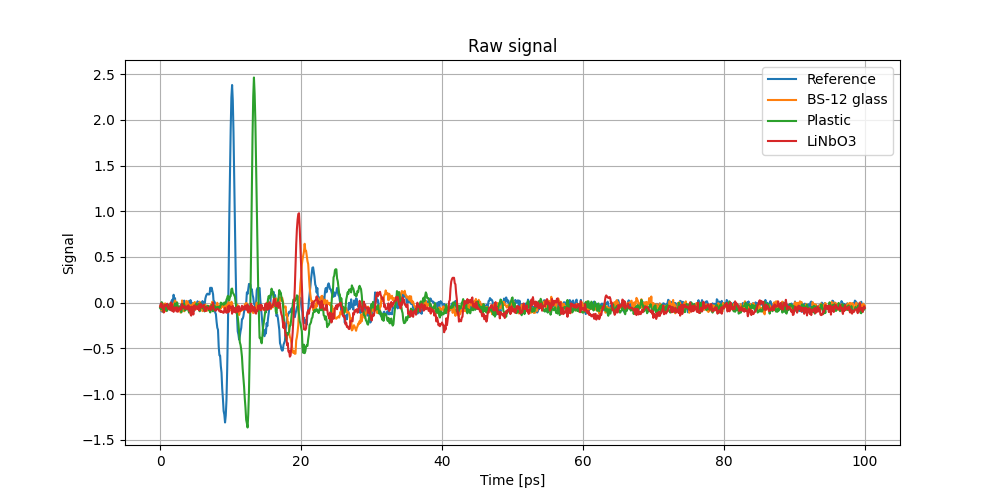

In [3]:
fig1 = plt.figure(figsize=(10,5))

ax1 = fig1.add_subplot(111)
ax1.set_title(r'Raw signal')
ax1.plot(time_ps, signal_ref, label="Reference")
ax1.plot(time_ps, signal_glass, label="BS-12 glass")
ax1.plot(time_ps, signal_plastic, label="Plastic")
ax1.plot(time_ps, signal_linbo3, label="LiNbO3")
ax1.set_xlabel('Time [ps]')
ax1.set_ylabel('Signal')
ax1.grid()
ax1.legend()

In [4]:
f_max_thz = 1/(2 * (time_ps[1] - time_ps[0]))

freqs_thz = np.linspace(-f_max_thz, f_max_thz, time_ps.shape[0])

spec_ref = np.fft.fftshift(np.fft.fft(signal_ref, norm='ortho'))
spec_glass = np.fft.fftshift(np.fft.fft(signal_glass, norm='ortho'))
spec_plastic = np.fft.fftshift(np.fft.fft(signal_plastic, norm='ortho'))
spec_linbo3 = np.fft.fftshift(np.fft.fft(signal_linbo3, norm='ortho'))

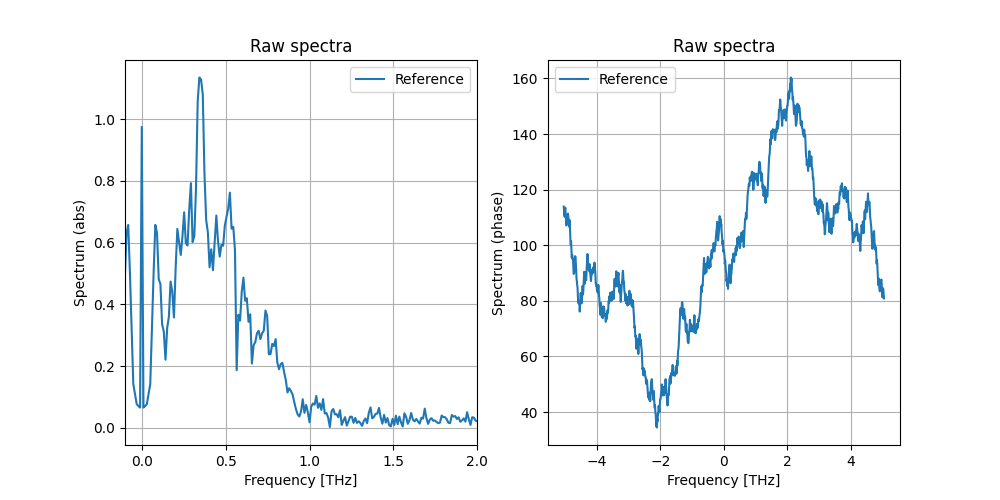

In [5]:
fig2 = plt.figure(figsize=(10,5))

ax1 = fig2.add_subplot(121)
ax1.set_title(r'Raw spectra')
ax1.plot(freqs_thz, np.abs(spec_ref), label="Reference")
# ax1.plot(freqs_thz, np.abs(spec_glass), label="BS-12 glass")
# ax1.plot(freqs_thz, np.abs(spec_plastic), label="Plastic")
# ax1.plot(freqs_thz, np.abs(spec_linbo3), label="LiNbO3")
ax1.set_xlabel('Frequency [THz]')
ax1.set_ylabel('Spectrum (abs)')
ax1.set_xlim(left=-0.1, right=2.0)
ax1.grid()
ax1.legend()

ax1 = fig2.add_subplot(122)
ax1.set_title(r'Raw spectra')
ax1.plot(freqs_thz, np.unwrap(np.angle(spec_ref, deg=True)), label="Reference")
# ax1.plot(freqs_thz, np.angle(spec_glass, deg=True), label="BS-12 glass")
# ax1.plot(freqs_thz, np.angle(spec_plastic, deg=True), label="Plastic")
# ax1.plot(freqs_thz, np.angle(spec_linbo3, deg=True), label="LiNbO3")
ax1.set_xlabel('Frequency [THz]')
ax1.set_ylabel('Spectrum (phase)')
# ax1.set_xlim(left=-0.1, right=2.0)
ax1.grid()
ax1.legend()

### Pre-processing

In [6]:
def super_gauss(time_arr: np.ndarray, tmin: float, tmax: float, p: int = 20):
    sigma = (tmax - tmin) / 2
    t0 = (tmax + tmin) / 2
    return np.exp(-((time_arr - t0)**2 / (2 * sigma**2))**p)

In [7]:
avg_len_ref = 60
avg_len_glass = 150
avg_len_plastic = 80
avg_len_linbo3 = 150

tmin_ref = 6
tmax_ref = 14

tmin_glass = 17
tmax_glass = 23

tmin_plastic = 9
tmax_plastic = 16

tmin_linbo3 = 16
tmax_linbo3 = 22

In [8]:
new_signal_ref = signal_ref * super_gauss(time_arr=time_ps, tmin=tmin_ref, tmax=tmax_ref) #- np.mean(signal_ref[:avg_len_ref])
new_signal_glass = signal_glass * super_gauss(time_arr=time_ps, tmin=tmin_glass, tmax=tmax_glass) #- np.mean(signal_glass[:avg_len_glass])
new_signal_plastic = signal_plastic * super_gauss(time_arr=time_ps, tmin=tmin_plastic, tmax=tmax_plastic) #- np.mean(signal_plastic[:avg_len_plastic])
new_signal_linbo3 = signal_linbo3 * super_gauss(time_arr=time_ps, tmin=tmin_linbo3, tmax=tmax_linbo3) #- np.mean(signal_linbo3[:avg_len_linbo3])

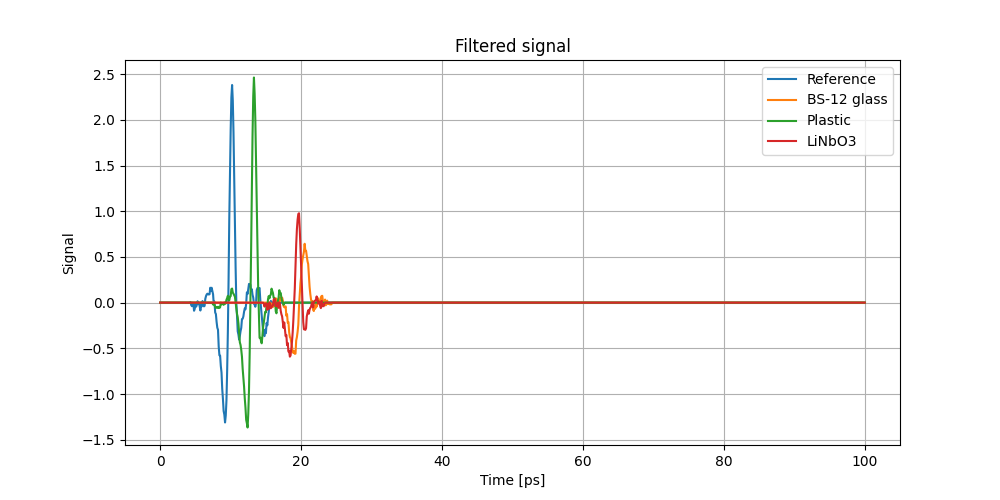

In [9]:
fig3 = plt.figure(figsize=(10,5))

ax1 = fig3.add_subplot(111)
ax1.set_title(r'Filtered signal')
ax1.plot(time_ps, new_signal_ref, label="Reference")
ax1.plot(time_ps, new_signal_glass, label="BS-12 glass")
ax1.plot(time_ps, new_signal_plastic, label="Plastic")
ax1.plot(time_ps, new_signal_linbo3, label="LiNbO3")
ax1.set_xlabel('Time [ps]')
ax1.set_ylabel('Signal')
ax1.grid()
ax1.legend()

### Fourier Transform

In [10]:
f_max_thz = 1/(2 * (time_ps[1] - time_ps[0]))

freqs_thz = np.linspace(-f_max_thz, f_max_thz, time_ps.shape[0])

new_spec_ref = np.fft.fftshift(np.fft.fft(new_signal_ref, norm='ortho'))
new_spec_glass = np.fft.fftshift(np.fft.fft(new_signal_glass, norm='ortho'))
new_spec_plastic = np.fft.fftshift(np.fft.fft(new_signal_plastic, norm='ortho'))
new_spec_linbo3 = np.fft.fftshift(np.fft.fft(new_signal_linbo3, norm='ortho'))

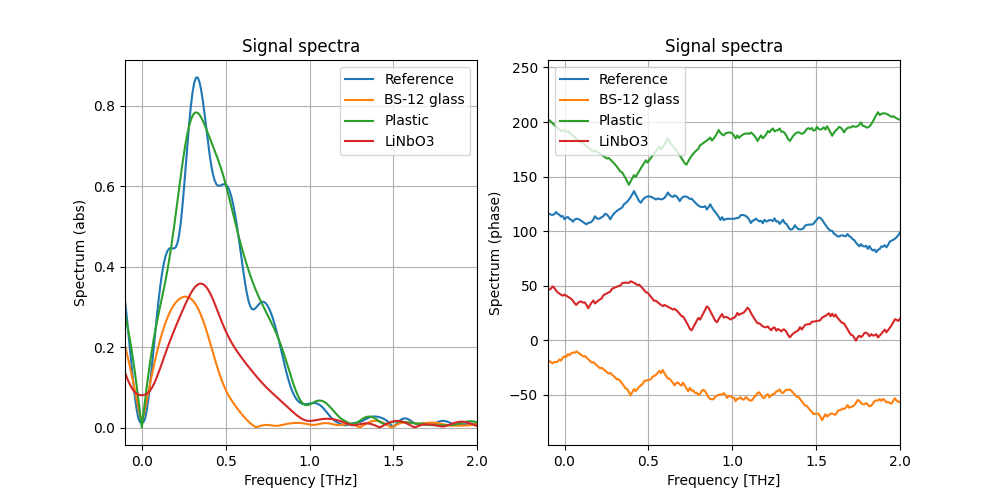

In [11]:
fig4 = plt.figure(figsize=(10,5))

ax1 = fig4.add_subplot(121)
ax1.set_title(r'Signal spectra')
ax1.plot(freqs_thz, np.abs(new_spec_ref), label="Reference")
ax1.plot(freqs_thz, np.abs(new_spec_glass), label="BS-12 glass")
ax1.plot(freqs_thz, np.abs(new_spec_plastic), label="Plastic")
ax1.plot(freqs_thz, np.abs(new_spec_linbo3), label="LiNbO3")
ax1.set_xlabel('Frequency [THz]')
ax1.set_ylabel('Spectrum (abs)')
ax1.set_xlim(left=-0.1, right=2.0)
ax1.grid()
ax1.legend()

ax1 = fig4.add_subplot(122)
ax1.set_title(r'Signal spectra')
ax1.plot(freqs_thz, np.unwrap(np.angle(new_spec_ref, deg=True)), label="Reference")
ax1.plot(freqs_thz, np.unwrap(np.angle(new_spec_glass, deg=True)), label="BS-12 glass")
ax1.plot(freqs_thz, np.unwrap(np.angle(new_spec_plastic, deg=True)), label="Plastic")
ax1.plot(freqs_thz, np.unwrap(np.angle(new_spec_linbo3, deg=True)), label="LiNbO3")
ax1.set_xlabel('Frequency [THz]')
ax1.set_ylabel('Spectrum (phase)')
ax1.set_xlim(left=-0.1, right=2.0)
ax1.grid()
ax1.legend()

### Refractive index calculation

In [12]:
h_glass = new_spec_glass / new_spec_ref
h_plastic = new_spec_plastic / new_spec_ref
h_linbo3 = new_spec_linbo3 / new_spec_ref

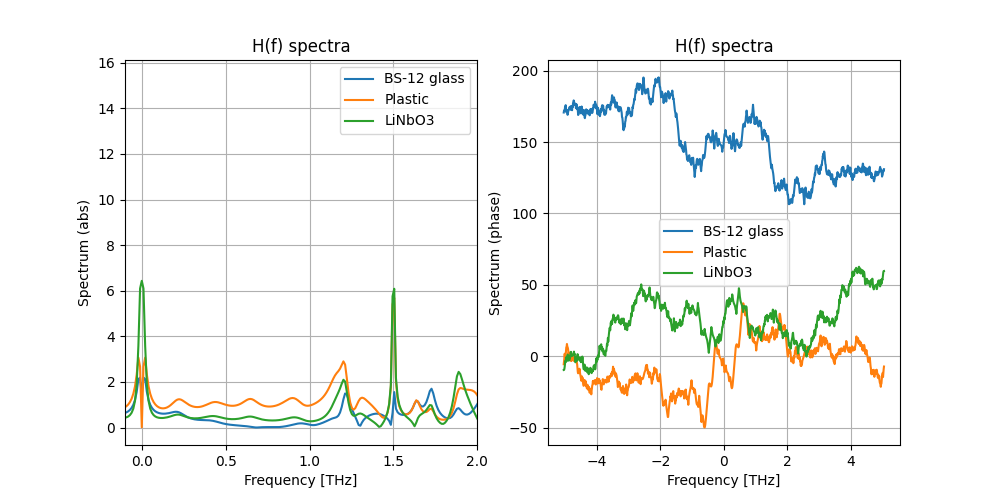

In [13]:
fig5 = plt.figure(figsize=(10,5))

ax1 = fig5.add_subplot(121)
ax1.set_title(r'H(f) spectra')
ax1.plot(freqs_thz, np.abs(h_glass), label="BS-12 glass")
ax1.plot(freqs_thz, np.abs(h_plastic), label="Plastic")
ax1.plot(freqs_thz, np.abs(h_linbo3), label="LiNbO3")
ax1.set_xlabel('Frequency [THz]')
ax1.set_ylabel('Spectrum (abs)')
ax1.set_xlim(left=-0.1, right=2.0)
ax1.grid()
ax1.legend()

ax1 = fig5.add_subplot(122)
ax1.set_title(r'H(f) spectra')
ax1.plot(freqs_thz, np.unwrap(np.angle(h_glass, deg=True)), label="BS-12 glass")
ax1.plot(freqs_thz, np.unwrap(np.angle(h_plastic, deg=True)), label="Plastic")
ax1.plot(freqs_thz, np.unwrap(np.angle(h_linbo3, deg=True)), label="LiNbO3")
ax1.set_xlabel('Frequency [THz]')
ax1.set_ylabel('Spectrum (phase)')
# ax1.set_xlim(left=-0.1, right=2.0)
ax1.grid()
ax1.legend()

In [14]:
n0 = 1
c = 3 * 10**8
omega = 2 * np.pi * freqs_thz * 10**12

l_glass = 2.11 * 10**(-3)
l_plastic = 2.18 * 10**(-3)
l_linbo3 = 0.5 * 10**(-3)

ns_glass = n0 - np.unwrap(np.angle(h_glass)) * c / (omega * l_glass)
ns_plastic = n0 - np.unwrap(np.angle(h_plastic)) * c / (omega * l_plastic)
ns_linbo3 = n0 - np.unwrap(np.angle(h_linbo3)) * c / (omega * l_linbo3)

C:\Users\isvoropaev\AppData\Local\Temp\ipykernel_38864\3755810672.py:9: RuntimeWarning: divide by zero encountered in divide
  ns_glass = n0 - np.unwrap(np.angle(h_glass)) * c / (omega * l_glass)
C:\Users\isvoropaev\AppData\Local\Temp\ipykernel_38864\3755810672.py:10: RuntimeWarning: divide by zero encountered in divide
  ns_plastic = n0 - np.unwrap(np.angle(h_plastic)) * c / (omega * l_plastic)
C:\Users\isvoropaev\AppData\Local\Temp\ipykernel_38864\3755810672.py:11: RuntimeWarning: divide by zero encountered in divide
  ns_linbo3 = n0 - np.unwrap(np.angle(h_linbo3)) * c / (omega * l_linbo3)


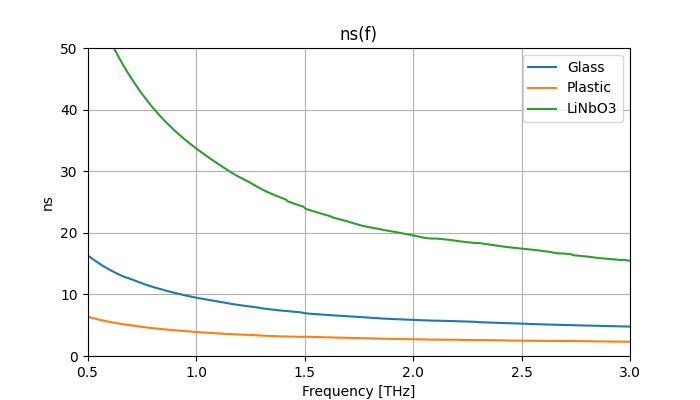

In [17]:
fig6 = plt.figure(figsize=(7,4))

ax1 = fig6.add_subplot(111)
ax1.set_title(r'ns(f)')
ax1.plot(freqs_thz, np.abs(ns_glass), label="Glass")
ax1.plot(freqs_thz, np.abs(ns_plastic), label="Plastic")
ax1.plot(freqs_thz, np.abs(ns_linbo3), label="LiNbO3")
ax1.set_xlabel('Frequency [THz]')
ax1.set_ylabel('ns')
ax1.set_xlim(left=0.5, right=3.0)
ax1.set_ylim(bottom=0, top=50)
ax1.grid()
ax1.legend()